# Table of Contents

- Logistic Regression in Depth
- Logistic Regression: Minimal Example
- K-Nearest Neighbors (KNN) Algorithm
- Decision Tree Algorithm
- Random Forest Algorithm
- Model Comparison
- Parameter vs Hyperparameter


# Logistic Regression: From Linear to Probability

A comprehensive guide to understanding logistic regression with visualizations using matplotlib and seaborn

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
print("Libraries imported successfully!")

Libraries imported successfully!


**1. The Problem: Pass or Fail?**

Can we predict if a student will pass based on study hours?

Training Data:


Study Hours,Result,Label
1,0,Fail
2,0,Fail
5,1,Pass
8,1,Pass


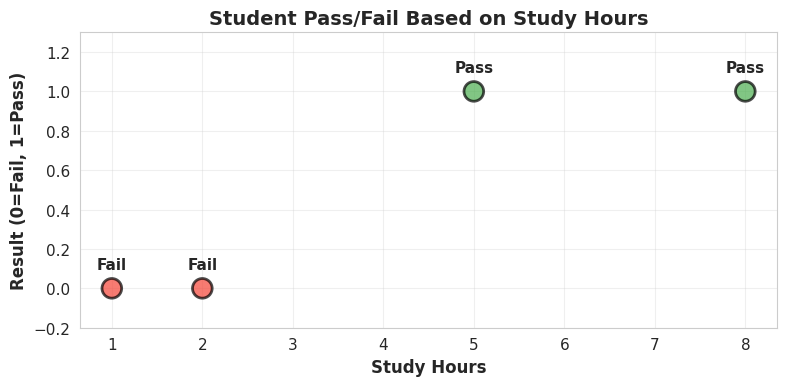

In [46]:
# @title
# Training data
study_hours = np.array([1, 2, 5, 8])
pass_fail = np.array([0, 0, 1, 1])
# Create DataFrame
data = pd.DataFrame({ 'Study Hours': study_hours,'Result': pass_fail,'Label': ['Fail', 'Fail', 'Pass', 'Pass']})
print("Training Data:")
# print(data)
display(HTML(data.to_html(index=False)))
# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#F44336' if x == 0 else '#4CAF50' for x in pass_fail]
ax.scatter(study_hours, pass_fail, s=200, c=colors, alpha=0.7, edgecolors='black', linewidth=2)
for i, (hour, result) in enumerate(zip(study_hours, pass_fail)):
    label = 'Fail' if result == 0 else 'Pass'
    ax.text(hour, result + 0.1, label, ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Study Hours', fontsize=12, fontweight='bold')
ax.set_ylabel('Result (0=Fail, 1=Pass)', fontsize=12, fontweight='bold')
ax.set_title('Student Pass/Fail Based on Study Hours', fontsize=14, fontweight='bold')
ax.set_ylim(-0.2, 1.3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**2. Why Not use Linear Regression for Classification?**

Linear regression produces invalid probabilities (can be negative or > 1)

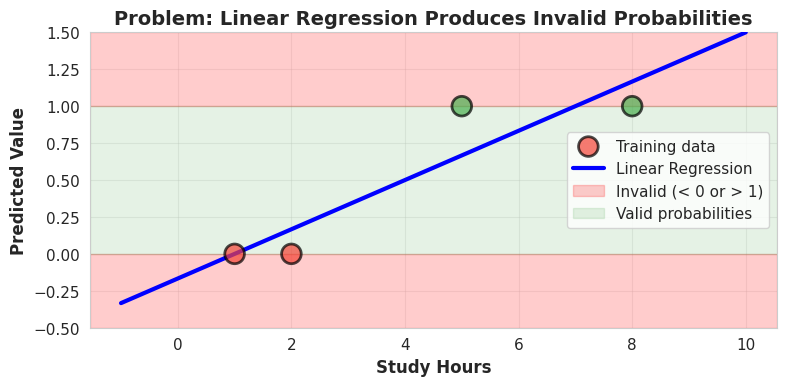

Linear model: y = 0.167x + -0.167
At x=0: -0.167 (INVALID!)
At x=9: 1.333 (INVALID!)


In [47]:
# @title
# Fit linear regression
X = study_hours.reshape(-1, 1)
linear_model = LinearRegression()
linear_model.fit(X, pass_fail)
# Predictions
x_range = np.linspace(-1, 10, 100).reshape(-1, 1)
linear_pred = linear_model.predict(x_range)
fig, ax = plt.subplots(figsize=(8, 4))
# Plot data and line
colors = ['#F44336' if x == 0 else '#4CAF50' for x in pass_fail]
ax.scatter(study_hours, pass_fail, s=200, c=colors, alpha=0.7, edgecolors='black', linewidth=2, label='Training data', zorder=5)
ax.plot(x_range, linear_pred, 'r-', color='blue', linewidth=3, label='Linear Regression', zorder=3)
# Highlight invalid regions
ax.axhspan(-0.5, 0, alpha=0.2, color='red', label='Invalid (< 0 or > 1)')
ax.axhspan(1, 1.5, alpha=0.2, color='red')
ax.axhspan(0, 1, alpha=0.1, color='green', label='Valid probabilities')
ax.set_xlabel('Study Hours', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Value', fontsize=12, fontweight='bold')
ax.set_title('Problem: Linear Regression Produces Invalid Probabilities', fontsize=14, fontweight='bold')
ax.set_ylim(-0.5, 1.5)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Linear model: y = {linear_model.coef_[0]:.3f}x + {linear_model.intercept_:.3f}")
print(f"At x=0: {linear_model.predict([[0]])[0]:.3f} (INVALID!)")
print(f"At x=9: {linear_model.predict([[9]])[0]:.3f} (INVALID!)")

In [48]:
# marks = w*study_hours + b  [mx+c] -> y = mx + c [-inf, +inf] -> continuous -> 0 - 1/
# classification -> probability -> 0 - 1
# print(marks)

# lr - p = wx + b
# lg - p = sigmoid(wx+b)

In [49]:
# @title
import numpy as np
import plotly.graph_objects as go

# 1. Define sigmoid with clipping for stability
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# 2. Generate values
z = np.linspace(-8, 8, 1000)
sigma_z = sigmoid(z)

# 3. Create the interactive figure
fig = go.Figure()

# Add the main sigmoid curve
fig.add_trace(go.Scatter(
    x=z, y=sigma_z,
    mode='lines',
    name='Sigmoid: σ(z)',
    line=dict(color='blue', width=3),
    fill='tozeroy',
    fillcolor='rgba(0, 0, 255, 0.1)'
))

# Add the Decision Threshold line
fig.add_hline(y=0.5, line_dash="dash", line_color="red",
              annotation_text="Decision Threshold (0.5)",
              annotation_position="bottom right")

# 4. Add Key Points as interactive markers
key_z = [-5, 0, 5]
key_sigma = [sigmoid(zp) for zp in key_z]

fig.add_trace(go.Scatter(
    x=key_z,
    y=key_sigma,
    mode='markers+text',
    name='Key Points',
    marker=dict(size=12, color='darkblue'),
    text=[f"z={zp}<br>σ={sigmoid(zp):.3f}" for zp in key_z],
    textposition="top center",
    hoverinfo='text'
))

# 5. Update Layout for a clean look
fig.update_layout(
    title='<b>The Sigmoid Function: Bounded to [0, 1]</b>',
    xaxis_title='<b>z (linear combination)</b>',
    yaxis_title='<b>Probability σ(z)</b>',
    yaxis=dict(range=[-0.1, 1.1]),
    template='plotly_white',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show()

# Print console properties
print("Sigmoid Properties:")
print(f"σ(-5) = {sigmoid(-5):.6f} -> Close to 0%")
print(f"σ(0)  = {sigmoid(0):.6f} -> 50%")
print(f"σ(5)  = {sigmoid(5):.6f} -> Close to 100%")

Sigmoid Properties:
σ(-5) = 0.006693 -> Close to 0%
σ(0)  = 0.500000 -> 50%
σ(5)  = 0.993307 -> Close to 100%


### 3. The Sigmoid Function
Transforms any input into a probability between 0 and 1:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

In [50]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

sigmoid(0.0)

# ouput = wx + b
# output = sigmoid(wx+b)

np.float64(0.5)

### 4. Logistic Regression: Two Steps

**Step 1: Linear Equation**

$$
\text{marks} = w \times \text{hours} + b
$$
$$
y = mx + c
$$
$$
z = wx + b
$$

**Step 2: Sigmoid Function**

$$
p = \sigma(z)
$$

Logistic Regression Model:
z = 0.9063 * hours + -3.3554
p = sigmoid(z)


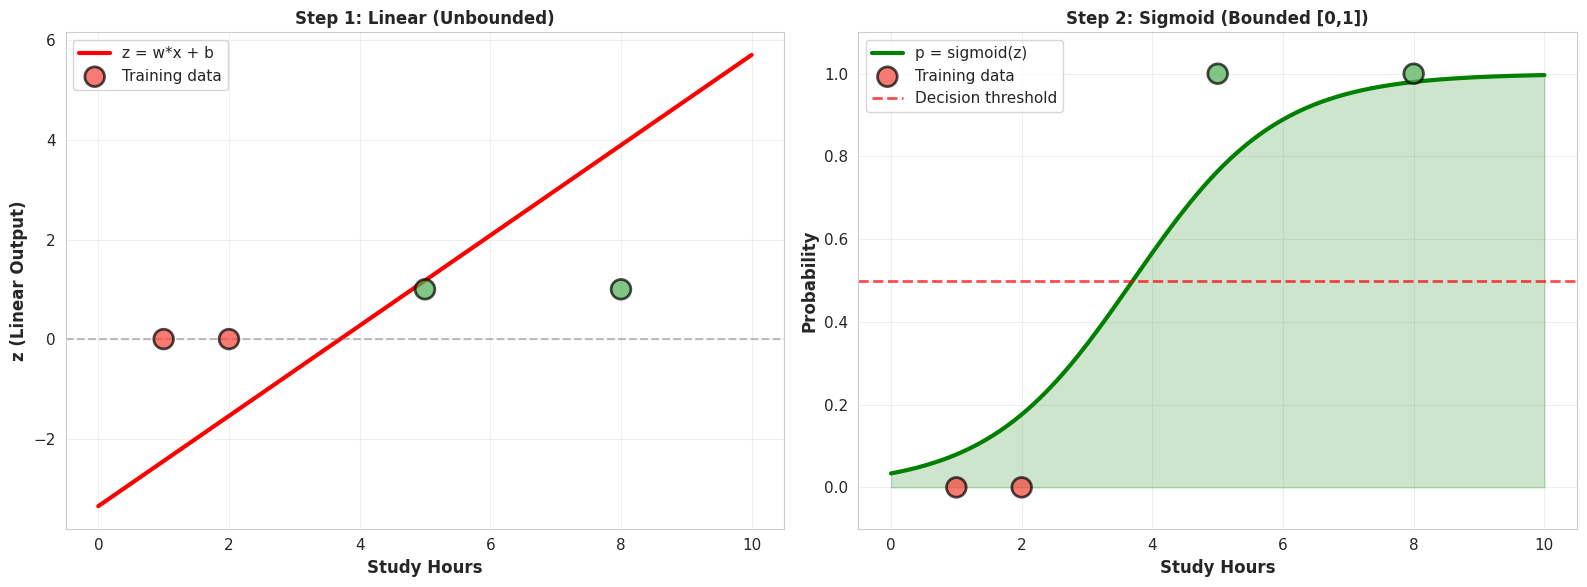

In [51]:
# @title
# Fit logistic regression
log_model = LogisticRegression()
log_model.fit(X, pass_fail)

w = log_model.coef_[0][0]
b = log_model.intercept_[0]

print("Logistic Regression Model:")
print(f"z = {w:.4f} * hours + {b:.4f}")
print("p = sigmoid(z)")

# Predictions
x_range_fine = np.linspace(0, 10, 300).reshape(-1, 1)

z_range = w * x_range_fine.flatten() + b
logistic_pred = sigmoid(z_range)

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -----------------------------
# Step 1: Linear
# -----------------------------
ax = axes[0]

ax.plot(
    x_range_fine,
    z_range,
    'r-',
    linewidth=3,
    label='z = w*x + b'
)

ax.scatter(
    study_hours,
    pass_fail,
    s=200,
    c=['#F44336', '#F44336', '#4CAF50', '#4CAF50'],
    alpha=0.7,
    edgecolors='black',
    linewidth=2,
    label='Training data',
    zorder=5
)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Study Hours', fontsize=12, fontweight='bold')
ax.set_ylabel('z (Linear Output)', fontsize=12, fontweight='bold')
ax.set_title('Step 1: Linear (Unbounded)', fontsize=12, fontweight='bold')

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# -----------------------------
# Step 2: Sigmoid
# -----------------------------
ax = axes[1]

ax.plot(
    x_range_fine,
    logistic_pred,
    'g-',
    linewidth=3,
    label='p = sigmoid(z)'
)

ax.scatter(
    study_hours,
    pass_fail,
    s=200,
    c=['#F44336', '#F44336', '#4CAF50', '#4CAF50'],
    alpha=0.7,
    edgecolors='black',
    linewidth=2,
    label='Training data',
    zorder=5
)

ax.axhline(
    y=0.5,
    color='red',
    linestyle='--',
    linewidth=2,
    alpha=0.7,
    label='Decision threshold'
)

ax.fill_between(
    x_range_fine.flatten(),
    0,
    logistic_pred,
    alpha=0.2,
    color='green'
)

ax.set_xlabel('Study Hours', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability', fontsize=12, fontweight='bold')

ax.set_title(
    'Step 2: Sigmoid (Bounded [0,1])',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylim(-0.1, 1.1)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**5. Worked Example: 6-Hour Student**

In [52]:
# @title
import numpy as np
import plotly.graph_objects as go

# --- Formatting Constants ---
BOLD = '\033[1m'
GREEN = '\033[92m'
BLUE = '\033[94m'
RED = '\033[91m'
END = '\033[0m'

# --- Setup Data & Model ---
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# Mock values for w and training data
w = 0.8
b = -3.5 # Adjusted to make 6 hours a "Pass" scenario
hours_test = 6
study_hours = np.array([1, 2, 5, 8])
pass_fail = np.array([0, 0, 1, 1])

# Step 1: Linear output
z_test = w * hours_test + b

# Step 2: Sigmoid probability
prob_test = sigmoid(z_test)
prediction = f"{GREEN}PASS{END}" if prob_test >= 0.5 else f"{RED}FAIL{END}"

# --- Styled Print Function ---
print(f"{BOLD}Student studies {hours_test} hours{END}")
print(f"\nStep 1: z = {w:.4f} * {hours_test} + {b:.4f} = {BOLD}{z_test:.4f}{END}")
print(f"Step 2: σ({z_test:.4f}) = {BOLD}{prob_test:.4f}{END}")
print(f"\nResult: {BLUE}{prob_test * 100:.1f}%{END} probability of {BOLD}PASSING{END}")
print(f"Decision: {BOLD}{prediction}{END}")

# --- Interactive Visualization ---
x_range_fine = np.linspace(0, 10, 500)
logistic_pred = sigmoid(w * x_range_fine + b)

fig = go.Figure()

# 1. Logistic Curve
fig.add_trace(go.Scatter(
    x=x_range_fine, y=logistic_pred,
    mode='lines', name='Logistic Curve',
    line=dict(color='green', width=3, shape='spline')
))

# 2. Training Data
fig.add_trace(go.Scatter(
    x=study_hours, y=pass_fail,
    mode='markers', name='Training Data',
    marker=dict(
        size=15,
        color=['red' if p == 0 else 'green' for p in pass_fail],
        line=dict(width=2, color='black')
    ),
    hovertemplate="Hours: %{x}<br>Actual: %{y}"
))

# 3. Test Prediction Point
fig.add_trace(go.Scatter(
    x=[hours_test], y=[prob_test],
    mode='markers', name=f'{hours_test}-hour Student',
    marker=dict(size=18, color='darkblue', symbol='diamond'),
    hovertemplate="<b>Test Student</b><br>Hours: %{x}<br>Prob: %{y:.4f}"
))

# 4. Decision Threshold Line
fig.add_hline(y=0.5, line_dash="dash", line_color="red", opacity=0.5,
              annotation_text="Threshold (0.5)")

# Layout Formatting
fig.update_layout(
    # title=f'<b>Prediction for {hours_test}-Hour Student</b>',
    title={
        'text': "<b>Student Success Analysis</b><br><span style='font-size:14px'>Predicting Probability of 'PASS' for 6 Hours of Study via Logistic Regression</span>",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title='<b>Study Hours</b>',
    yaxis_title='<b>Probability of Passing</b>',
    yaxis=dict(range=[-0.1, 1.1]),
    template='plotly_white',
    hovermode='closest'
)

fig.show()

Student studies 6 hours

Step 1: z = 0.8000 * 6 + -3.5000 = 1.3000
Step 2: σ(1.3000) = 0.7858

Result: 78.6% probability of PASSING
Decision: PASS


### 6. Loss Functions: Cross-Entropy vs MSE

**Cross-Entropy Loss**

$$
\text{Loss} = -\left[y \log(p) + (1-y)\log(1-p)\right]
$$

**Mean Squared Error (MSE)**

$$
\text{MSE} = (y - p)^2
$$

In [53]:
# z = w*4+ b = 4.5
# p = sigmoid(z) = 0.95
# y = 1

LOSS COMPARISON DATA
Cross-Entropy
  y=1, p=0.95: 0.0513 (Correct)
  y=1, p=0.05: 2.9957 (Very Wrong)

Mean Squared Error (MSE)
  y=1, p=0.95: 0.0025 (Correct)
  y=1, p=0.05: 0.9025 (Very Wrong)

LOG LOSS (CROSS-ENTROPY) ADVANTAGE:
Notice the Left Plot: As the prediction gets worse, the loss increases exponentially.
This forces the model to learn much faster than MSE.

THE MSE SATURATION PROBLEM:
Notice the Right Plot: When the model is confidently wrong, the curve goes flat.
This is called a 'Gradient Vanishing' effect where learning almost stops.


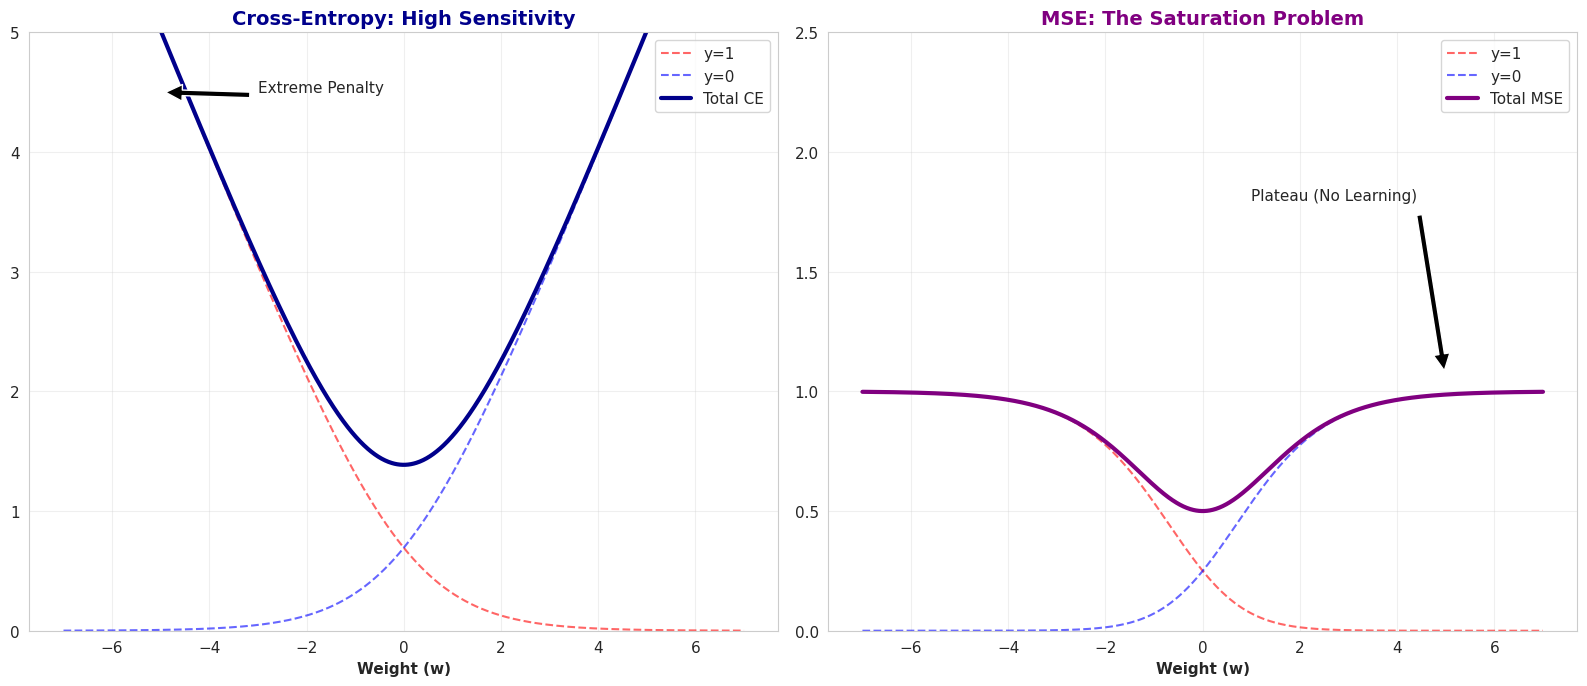

In [54]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# --- Logic Functions ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def mse_loss(y, p):
    return (y - p) ** 2

def ce_loss(y, p):
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

# --- Setup & Calculations ---
BOLD, BLUE, RED, GREEN, CYAN, END = '\033[1m', '\033[94m', '\033[91m', '\033[92m', '\033[96m', '\033[0m'

w = np.linspace(-7, 7, 1000)
p_vals = sigmoid(w)

mse_total = mse_loss(1, p_vals) + mse_loss(0, p_vals)
ce_total = ce_loss(1, p_vals) + ce_loss(0, p_vals)

# --- 1. PRINT SECTION (Text first to prevent UI flickering) ---
print(f"{BOLD}{BLUE}LOSS COMPARISON DATA{END}")
print(f"{BOLD}Cross-Entropy{END}")
print(f"  y=1, p=0.95: {GREEN}{ce_loss(1, 0.95):.4f}{END} (Correct)")
print(f"  y=1, p=0.05: {RED}{ce_loss(1, 0.05):.4f}{END} (Very Wrong)")

print(f"\n{BOLD}Mean Squared Error (MSE){END}")
print(f"  y=1, p=0.95: {GREEN}{mse_loss(1, 0.95):.4f}{END} (Correct)")
print(f"  y=1, p=0.05: {RED}{mse_loss(1, 0.05):.4f}{END} (Very Wrong)")

print()

# --- Styled Report ---
print(f"{BOLD}{BLUE}LOG LOSS (CROSS-ENTROPY) ADVANTAGE:{END}")
print(f"Notice the {BOLD}Left Plot{END}: As the prediction gets worse, the loss increases {RED}exponentially{END}.")
print(f"This forces the model to learn much faster than MSE.")

print(f"\n{BOLD}{RED}THE MSE SATURATION PROBLEM:{END}")
print(f"Notice the {BOLD}Right Plot{END}: When the model is confidently wrong, the curve goes {BOLD}flat{END}.")
print(f"This is called a 'Gradient Vanishing' effect where learning almost stops.")

# --- 2. PLOT SECTION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

# Left: Cross-Entropy
axes[0].plot(w, ce_loss(1, p_vals), 'r--', alpha=0.6, label='y=1')
axes[0].plot(w, ce_loss(0, p_vals), 'b--', alpha=0.6, label='y=0')
axes[0].plot(w, ce_total, 'darkblue', lw=3, label='Total CE')
axes[0].set_title('Cross-Entropy: High Sensitivity', fontsize=14, fontweight='bold', color='darkblue')
axes[0].set_ylim(0, 5)
axes[0].annotate('Extreme Penalty', xy=(-5, 4.5), xytext=(-3, 4.5), arrowprops=dict(facecolor='black', shrink=0.05))

# Right: MSE
axes[1].plot(w, mse_loss(1, p_vals), 'r--', alpha=0.6, label='y=1')
axes[1].plot(w, mse_loss(0, p_vals), 'b--', alpha=0.6, label='y=0')
axes[1].plot(w, mse_total, 'purple', lw=3, label='Total MSE')
axes[1].set_title('MSE: The Saturation Problem', fontsize=14, fontweight='bold', color='purple')
axes[1].set_ylim(0, 2.5)
axes[1].annotate('Plateau (No Learning)', xy=(5, 1.05), xytext=(1, 1.8), arrowprops=dict(facecolor='black', shrink=0.05))

for ax in axes:
    ax.set_xlabel('Weight (w)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show() # <--- Keep this as the absolute last line

7. Linear vs Logistic Output Comparison

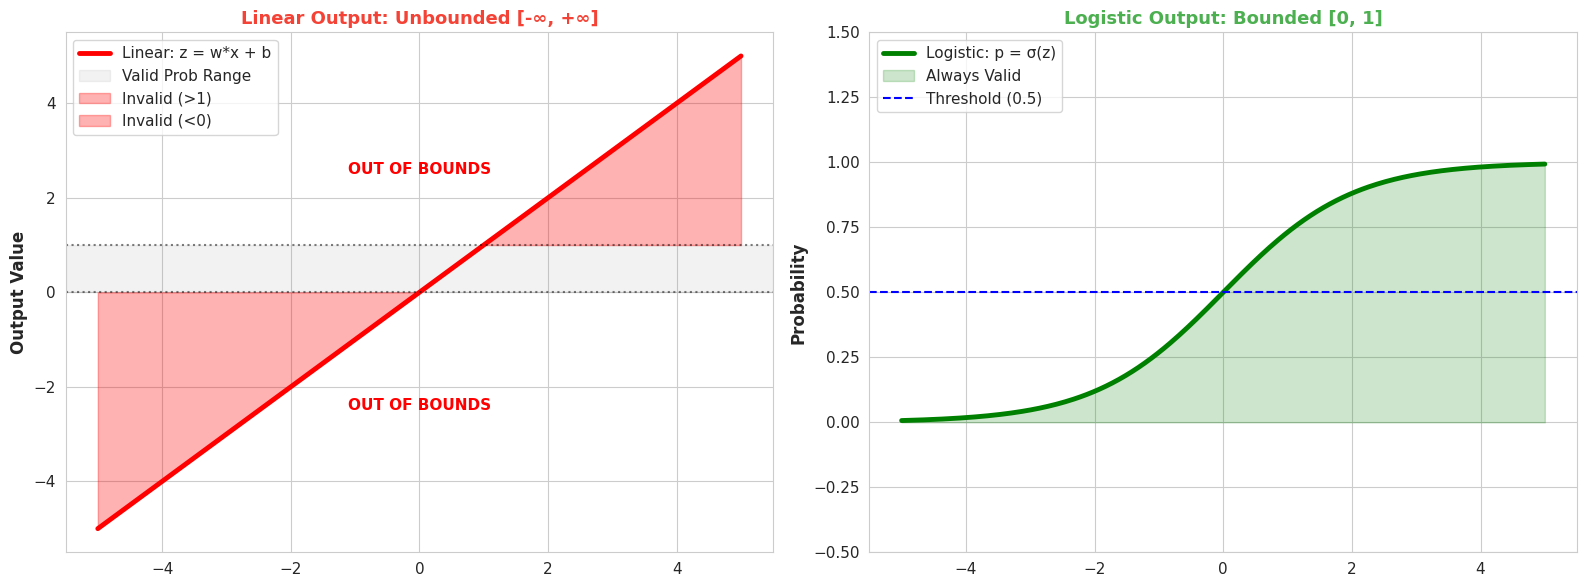

LINEAR REGRESSION PROBLEM:
Values can be Negative or Greater than 100%, which makes no sense for probability.

LOGISTIC REGRESSION SOLUTION:
The Sigmoid function asymptotically crushes all inputs into the strict [0, 1] range.


In [55]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# Define sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# Generate values
z_vals = np.linspace(-5, 5, 300)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Formatting Constants ---
BOLD = '\033[1m'
RED_TEXT = '\033[91m'
GREEN_TEXT = '\033[92m'
END = '\033[0m'

# -----------------------------
# Linear Output (THE FIX)
# -----------------------------
ax = axes[0]
ax.plot(z_vals, z_vals, 'r-', linewidth=3.5, label='Linear: z = w*x + b')

# Highlight the VALID range [0, 1]
ax.axhspan(0, 1, color='gray', alpha=0.1, label='Valid Prob Range')
ax.axhline(y=1, color='black', linestyle=':', alpha=0.5)
ax.axhline(y=0, color='black', linestyle=':', alpha=0.5)

# Fill areas that are INVALID (below 0 and above 1)
ax.fill_between(z_vals, z_vals, 1, where=(z_vals > 1), color='red', alpha=0.3, label='Invalid (>1)')
ax.fill_between(z_vals, z_vals, 0, where=(z_vals < 0), color='red', alpha=0.3, label='Invalid (<0)')

ax.set_title('Linear Output: Unbounded [-∞, +∞]', fontsize=13, fontweight='bold', color='#F44336')
ax.set_ylabel('Output Value', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')

ax.text(0, 2.5, 'OUT OF BOUNDS', color='red', fontweight='bold', ha='center')
ax.text(0, -2.5, 'OUT OF BOUNDS', color='red', fontweight='bold', ha='center')

# -----------------------------
# Logistic Output
# -----------------------------
ax = axes[1]
logistic_vals = sigmoid(z_vals)
ax.plot(z_vals, logistic_vals, 'g-', linewidth=3.5, label='Logistic: p = σ(z)')

# Fill the entire area because it's all valid
ax.fill_between(z_vals, 0, logistic_vals, alpha=0.2, color='green', label='Always Valid')
ax.axhline(y=0.5, color='blue', linestyle='--', linewidth=1.5, label='Threshold (0.5)')

ax.set_title('Logistic Output: Bounded [0, 1]', fontsize=13, fontweight='bold', color='#4CAF50')
ax.set_ylabel('Probability', fontsize=12, fontweight='bold')
ax.set_ylim(-0.5, 1.5) # Expanded slightly to show the bounds better
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Descriptive Console Output
print(f"{BOLD}{RED_TEXT}LINEAR REGRESSION PROBLEM:{END}")
print(f"Values can be {BOLD}Negative{END} or {BOLD}Greater than 100%{END}, which makes no sense for probability.")
print(f"\n{BOLD}{GREEN_TEXT}LOGISTIC REGRESSION SOLUTION:{END}")
print(f"The Sigmoid function {BOLD}asymptotically crushes{END} all inputs into the strict [0, 1] range.")

## 8. Why Not MSE for Logistic Regression?

### Problems with MSE

* **Saturation Problem:** Sigmoid gradients can become very small, causing learning to slow down or stop.

* **Non-Convex Loss:** Optimization can become difficult due to local minima.

* **Not Probability-Aware:** MSE treats all errors more uniformly, even when probability predictions are very wrong.

### Why Cross-Entropy is Better

* **Better Optimization:** Produces a smoother optimization landscape for logistic regression.

* **Stronger Gradients:** Encourages faster and more stable learning.

* **Probability-Aware:** Penalizes highly confident wrong predictions more heavily.


In [56]:
# @title
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 1. Logic Functions ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def ce_loss(y, p):
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

# --- 2. Setup Formatting & Data ---
BOLD, BLUE, RED, GREEN, CYAN, END = '\033[1m', '\033[94m', '\033[91m', '\033[92m', '\033[96m', '\033[0m'

X = np.array([[0.6, 0.6], [0.6, -0.6], [-0.6, 0.6], [-0.6, -0.6]])
y = np.array([1, 0, 0, 1])

w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)

MSE_Loss = np.zeros(W1.shape)
CE_Loss = np.zeros(W1.shape)

for i in range(len(X)):
    z = W1 * X[i,0] + W2 * X[i,1]
    p = sigmoid(z)
    MSE_Loss += (y[i] - p)**2
    CE_Loss += ce_loss(y[i], p)

# --- 3. Styled Print Report (First to ensure static UI) ---
# print(f"{BOLD}{CYAN}# --- 3D LOSS LANDSCAPE ANALYSIS --- #{END}")

print(f"\n{BOLD}{GREEN}LEFT: CROSS-ENTROPY (The Goal){END}")
print(f"Notice the {BOLD}Convex Bowl{END}. There is one clear global minimum.")
print(f"Gradient Descent can easily find the bottom, making training {BOLD}stable and fast{END}.")

print(f"\n{BOLD}{RED}RIGHT: MSE (The Problem){END}")
print(f"Notice the {BOLD}Non-Convex Landscape{END}. The surface is 'wavy' and complex.")
print(f"You can see {BOLD}multiple local minima{END} and flat plateaus where the model can get 'stuck'.")
print(f"This is why we avoid MSE for Logistic Regression.")
print("-" * 60)

# --- 4. Create Interactive Subplots ---
# Swapping Specs: CE Left (Col 1), MSE Right (Col 2)
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=(
        "<b>Cross-Entropy: Convex Landscape</b>",
        "<b>MSE Loss: Non-Convex (Multiple Local Minima)</b>"
    )
)

# Cross-Entropy Surface (LEFT)
fig.add_trace(
    go.Surface(
        z=CE_Loss, x=w1, y=w2,
        colorscale='Viridis',
        colorbar=dict(title='CE Loss', x=-0.07),
        name='Cross-Entropy'
    ),
    row=1, col=1
)

# MSE Surface (RIGHT)
fig.add_trace(
    go.Surface(
        z=MSE_Loss, x=w1, y=w2,
        colorscale='RdYlBu_r',
        colorbar=dict(title='MSE Loss', x=1.07),
        name='MSE'
    ),
    row=1, col=2
)

# --- 5. Layout Adjustments ---
fig.update_layout(
    title={
        'text': '<b>3D Loss Landscape Comparison: Cross-Entropy vs. MSE for Classification Task</b>',
        'x': 0.5,               # Centers the title horizontally (0 to 1)
        'xanchor': 'center',    # Ensures the anchor point is the middle of the text
        'yanchor': 'top'        # Aligns the top of the text to the coordinate
    },
    width=1300,
    height=700,
    margin=dict(l=100, r=100, b=50, t=100),
    scene=dict( # Scene for CE (Left)
        xaxis_title='w1', yaxis_title='w2', zaxis_title='Loss',
        zaxis=dict(range=[0, 10])
    ),
    scene2=dict( # Scene for MSE (Right)
        xaxis_title='w1', yaxis_title='w2', zaxis_title='Loss',
        zaxis=dict(range=[0, 4])
    )
)

fig.show()


LEFT: CROSS-ENTROPY (The Goal)
Notice the Convex Bowl. There is one clear global minimum.
Gradient Descent can easily find the bottom, making training stable and fast.

RIGHT: MSE (The Problem)
Notice the Non-Convex Landscape. The surface is 'wavy' and complex.
You can see multiple local minima and flat plateaus where the model can get 'stuck'.
This is why we avoid MSE for Logistic Regression.
------------------------------------------------------------


#### 9. Real-World Applications

| Domain     | Problem              | Class 0      | Class 1        |
|------------|---------------------|--------------|----------------|
| Email      | Spam Detection      | Not Spam     | Spam           |
| Medical    | Disease Diagnosis   | Healthy      | Has Disease    |
| Finance    | Loan Default        | Will Repay   | Will Default   |
| Marketing  | Ad Click Prediction | No Click     | Click          |
| Retention  | Customer Churn      | Will Stay    | Will Churn     |
| Education  | Student Pass/Fail   | Fail         | Pass           |

### 10. Logistic Regression: Complete Workflow & Mathematical Summary

#### 1. The Prediction Process

i. **Input:** Features ($x_1, x_2, \dots, x_n$)

ii. **Linear Combination:**

>  $z = w_1x_1 + w_2x_2 + \dots + b$
*(Unbounded output from $-\infty$ to $+\infty$)*


iii. **Activation (Sigmoid):**

> $p = \sigma(z) = \frac{1}{1 + e^{-z}}$
*(Squashes output to a valid probability range $[0, 1]$)*

iv. **Thresholding:** Apply a decision threshold (typically $0.5$).

v. **Classification:**
>
* **Class 1 (Pass/Yes):** If $p \geq 0.5$
* **Class 0 (Fail/No):** If $p < 0.5$



---

#### 2. The Loss Function (Binary Cross-Entropy)

To train the model, we use **Cross-Entropy Loss** rather than MSE:


$$\text{Loss} = -\left[y \cdot \log(p) + (1 - y)\cdot \log(1 - p)\right]$$

**Why it works:**

* **Convexity:** Creates a single "bowl" shape (Global Minimum), making optimization reliable.
* **Sensitivity:** Penalizes wrong predictions exponentially, forcing the model to learn faster.
* **Gradient Flow:** Avoids the "flat" plateaus found in MSE for classification.

---

#### 3. Optimization Logic

The goal is to minimize the Cost Function $J(w,b)$ across $m$ examples:


$$J(w,b) = \frac{1}{m} \sum_{i=1}^{m} \text{Loss}_i$$

**Gradient Descent Step:**

* $w := w - \alpha \cdot \frac{\partial J}{\partial w}$
* $b := b - \alpha \cdot \frac{\partial J}{\partial b}$

---

#### 4. Key Insights

* **Interpretable:** Logistic regression estimates **probability**, not just hard labels.
* **Foundation:** This same logic (Linear $\rightarrow$ Activation $\rightarrow$ Loss) is the fundamental building block of **Neural Networks**.
* **Efficiency:** It is computationally "cheap" and performs exceptionally well on linearly separable data.

# Minimal Example of Logistic Regression using Scikit Learn

In [57]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [58]:
# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [59]:
# Select features
df = df[["Pclass", "Sex", "Age", "Fare", "Survived"]]

In [60]:
# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median())

In [61]:
# Encode categorical column
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

In [62]:
# Features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [63]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [64]:
# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [65]:
# Model
model = LogisticRegression()

In [66]:
# Model
model = LogisticRegression()

In [67]:
# Train the model
model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)

In [68]:
# Probabilities for AUC
y_prob = model.predict_proba(X_test)[:, 1]

In [69]:
# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.7932960893854749
Precision: 0.7681159420289855
Recall   : 0.7162162162162162
F1 Score : 0.7412587412587412
ROC AUC  : 0.8745173745173744

Confusion Matrix:
 [[89 16]
 [21 53]]


# K-Nearest Neighbors (KNN)

KNN is one of the simplest machine learning algorithms.

The main idea:

> Look at the nearest data points, and predict based on what most of them are.

![](https://substackcdn.com/image/fetch/$s_!-q5-!,w_1456,c_limit,f_webp,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fd471b662-696e-4f70-b651-168958b6b39c_990x454.png)



#### **KNN Classification Pseudocode**
```

INPUT:
    Training data X
    Training labels Y
    New data point P
    Number of neighbors K

BEGIN

1. For each training point Xi in X:
    
    a. Calculate distance between P and Xi
    
    b. Store:
        (distance, corresponding label)

2. Sort all stored distances in ascending order

3. Select the first K nearest neighbors

4. Count how many times each class appears

5. Choose the class with highest count

6. Return predicted class

END
```


#### **Important Notes About KNN**

###### **1. KNN is a “Lazy Learner”**

KNN does not actually learn a mathematical model during training.

Most algorithms:

* learn patterns first
* then make predictions

But KNN simply:

* stores the training data
* waits until prediction time

That’s why it is called a **lazy learner**.

- Training is very fast
- Prediction can be slow

---

###### **2. KNN is Distance-Based**

KNN works by measuring distance between points.

Closer points are considered more similar.

Because of this, feature scaling is important.

Common distance metrics in KNN:

* **Euclidean Distance** → used most of the time
  Straight-line distance between two points.

 $ d = \sqrt{\sum_{i=1}^{n}(x_i-y_i)^2} $

* **Manhattan Distance**
  Distance measured by moving only horizontally and vertically (like city blocks).

 $ d = \sum_{i=1}^{n}|x_i-y_i|$

* **Minkowski Distance**
  Generalized version of Euclidean and Manhattan distance.

* **Hamming Distance**
  Used for categorical/binary data. Counts how many values differ.

* **Cosine Similarity / Cosine Distance**
  Measures angle similarity between vectors. Common in text/NLP tasks.

![](https://miro.medium.com/1*VteXrmdjFaJsqy4pz3JSTQ.png)

---

###### **3. KNN Has No Explicit Training Phase**

Unlike algorithms such as:

* Logistic Regression
* Decision Trees
* Neural Networks

KNN does not build equations or trees.

Training basically means:

> “Store the dataset.”

---

###### **4. Choice of K is Important**

* Small K → sensitive to noise (overfitting)
* Large K → too general (underfitting)

Typical values:

* K = 3
* K = 5
* K = 7

---

###### **5. KNN Can Be Slow for Large Datasets**

For every new prediction, KNN compares the new point with many existing points.

So:

* small dataset → fine
* huge dataset → slower predictions

---

###### **6. KNN Works for Both Classification and Regression**

* Classification → majority vote
* Regression → average of nearest values


   KNN OPTIMIZATION REPORT
Analysis range: K=1 to K=30
Minimum Error Rate: 0.1788

Conclusion: We will use K = 5,
because it gives us the least loss and the highest accuracy.
This point represents the optimal balance between Bias and Variance.


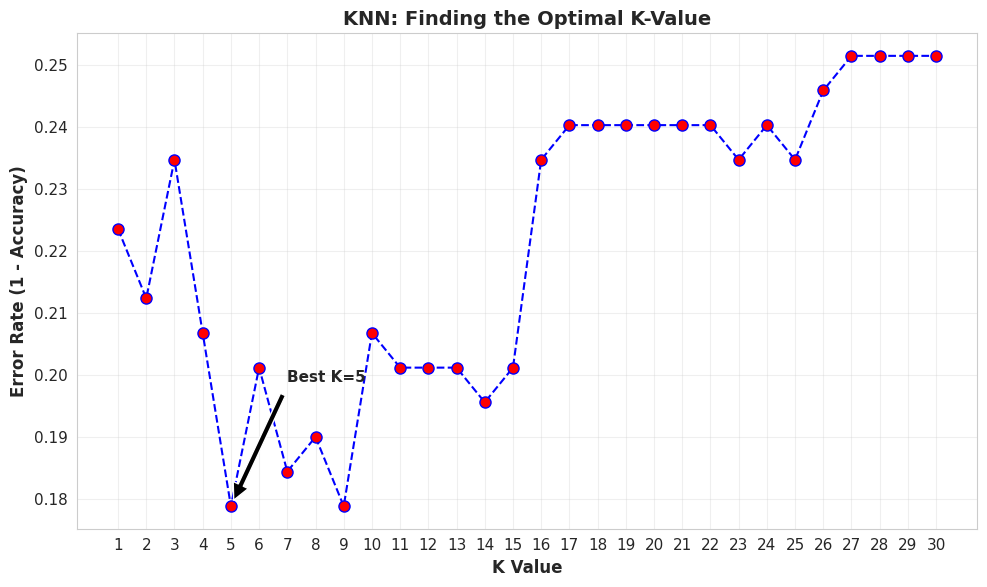

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# --- Formatting Constants ---
BOLD   = '\033[1m'
RED    = '\033[91m'
GREEN  = '\033[92m'
BLUE   = '\033[94m'
PURPLE = '\033[95m'
END    = '\033[0m'


# 1. Load and Clean Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df = df[["Pclass", "Sex", "Age", "Fare", "Survived"]]
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

X = df.drop("Survived", axis=1)
y = df["Survived"]

# 2. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Find optimal K
k_values = range(1, 31)
errors = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    errors.append(1 - acc)

# Identify the best K programmatically
min_error = min(errors)
best_k = k_values[np.argmin(errors)]

# 4. Styled Console Output (Print first for stability)
print(f"{BOLD}{BLUE}===================================================={END}")
print(f"{BOLD}   KNN OPTIMIZATION REPORT{END}")
print(f"{BOLD}{BLUE}===================================================={END}")
print(f"Analysis range: {BOLD}K=1 to K=30{END}")
print(f"Minimum Error Rate: {GREEN}{min_error:.4f}{END}")
print(f"\nConclusion: We will use {BOLD}{RED}K = {best_k}{END},")
print(f"because it gives us the {BOLD}least loss{END} and the {BOLD}highest accuracy{END}.")
print(f"This point represents the optimal balance between {PURPLE}Bias and Variance{END}.")
print(f"{BOLD}{BLUE}===================================================={END}")

# 5. Plot Error vs K
plt.figure(figsize=(10, 6))
plt.plot(k_values, errors, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)

# Highlight the best K point on the plot
plt.annotate(f'Best K={best_k}', xy=(best_k, min_error), xytext=(best_k+2, min_error+0.02),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontweight='bold')

plt.xlabel("K Value", fontsize=12, fontweight='bold')
plt.ylabel("Error Rate (1 - Accuracy)", fontsize=12, fontweight='bold')
plt.title("KNN: Finding the Optimal K-Value", fontsize=14, fontweight='bold')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Decision Tree Classifier


![](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEjq7iPacW7sZedJsEr1Uo3GluS3Qa0Lort9nmtJ1D4YaE9BuHctetFaS63dSPlYrd6N-OR_6uhyqESSY57f_fLQtEZN9VAcFf9GpPPsS_tS96SueadV_DTisQEGly8JMRTuF2XfVxU1Tott/s640/1.PNG)



#### 🌳 Decision Tree

A Decision Tree is a supervised machine learning algorithm used for **classification and regression**. It works like a flowchart of decisions. A Decision Tree makes predictions by repeatedly splitting data using the best feature until it reaches a final decision.

---

#### 🧠 Basic Idea

> “Ask a series of yes/no questions to reach a decision.”

Example:

* Is age > 18?
* Is income > 50K?
* Is credit score high?

Finally, you reach a prediction.

---

#### 🌳 How It Works

1. Start with the full dataset (root node)
2. Find the best feature to split the data
3. Split data into branches
4. Repeat recursively
5. Stop when:

   * data is pure (only one class)
   * or max depth is reached

---

#### 🔀 Example Structure

```
            Age > 30?
           /        \
        Yes          No
       /              \
  Income > 50K?     Class B
     /     \
 Class A   Class B
```

![](https://dataaspirant.com/wp-content/uploads/2017/01/B03905_05_01-compressor.png)




---

#### 📊 Splitting Criteria

Decision trees choose the best split using:

**1. Gini Impurity**


Measures how “mixed” a node is.

$$
Gini = 1 - \sum p_i^2
$$

* 0 → pure node
* higher → more impurity

---

**2. Entropy (Information Gain)**

Measures disorder in data.

$$
Entropy = -\sum p_i \log_2(p_i)
$$

Model tries to **reduce entropy** after split.

---

#### 🌱 Key Terms

**Root Node**

* First split of the tree

**Leaf Node**

* Final prediction (no more splits)

**Internal Node**

* Decision point in the tree

**Branch**

* Path from root to leaf

---

#### Advantages

- Easy to understand
- Works with numeric + categorical data
- No feature scaling needed
- Handles nonlinear relationships

---

#### Disadvantages

- Overfitting (very common)
- Sensitive to small data changes
- Can become very complex

---

#### Decision Tree Training

Decision Tree does have a training phase. During training, it learns how to split the data into smaller and smaller groups by choosing the best features and split points. The goal is to create rules that separate the classes as clearly as possible.

**What happens during training:**
- Tries different feature splits (e.g., Age < 30, Fare < 50)
- Chooses the best split using Gini impurity or Entropy
- Repeats splitting recursively for each branch
- Stops when nodes are pure or limits (like max depth) are reached


In [71]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Select features
df = df[["Pclass", "Sex", "Age", "Fare", "Survived"]]

# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median())

# Encode categorical column
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# Features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ⚠️ Note: Scaling is NOT required for Decision Trees
# Keeping it optional here (you can remove it safely)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = DecisionTreeClassifier(
    max_depth=5,      # helps reduce overfitting
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Probabilities for AUC
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.8044692737430168
Precision: 0.8305084745762712
Recall   : 0.6621621621621622
F1 Score : 0.7368421052631579
ROC AUC  : 0.861003861003861

Confusion Matrix:
 [[95 10]
 [25 49]]


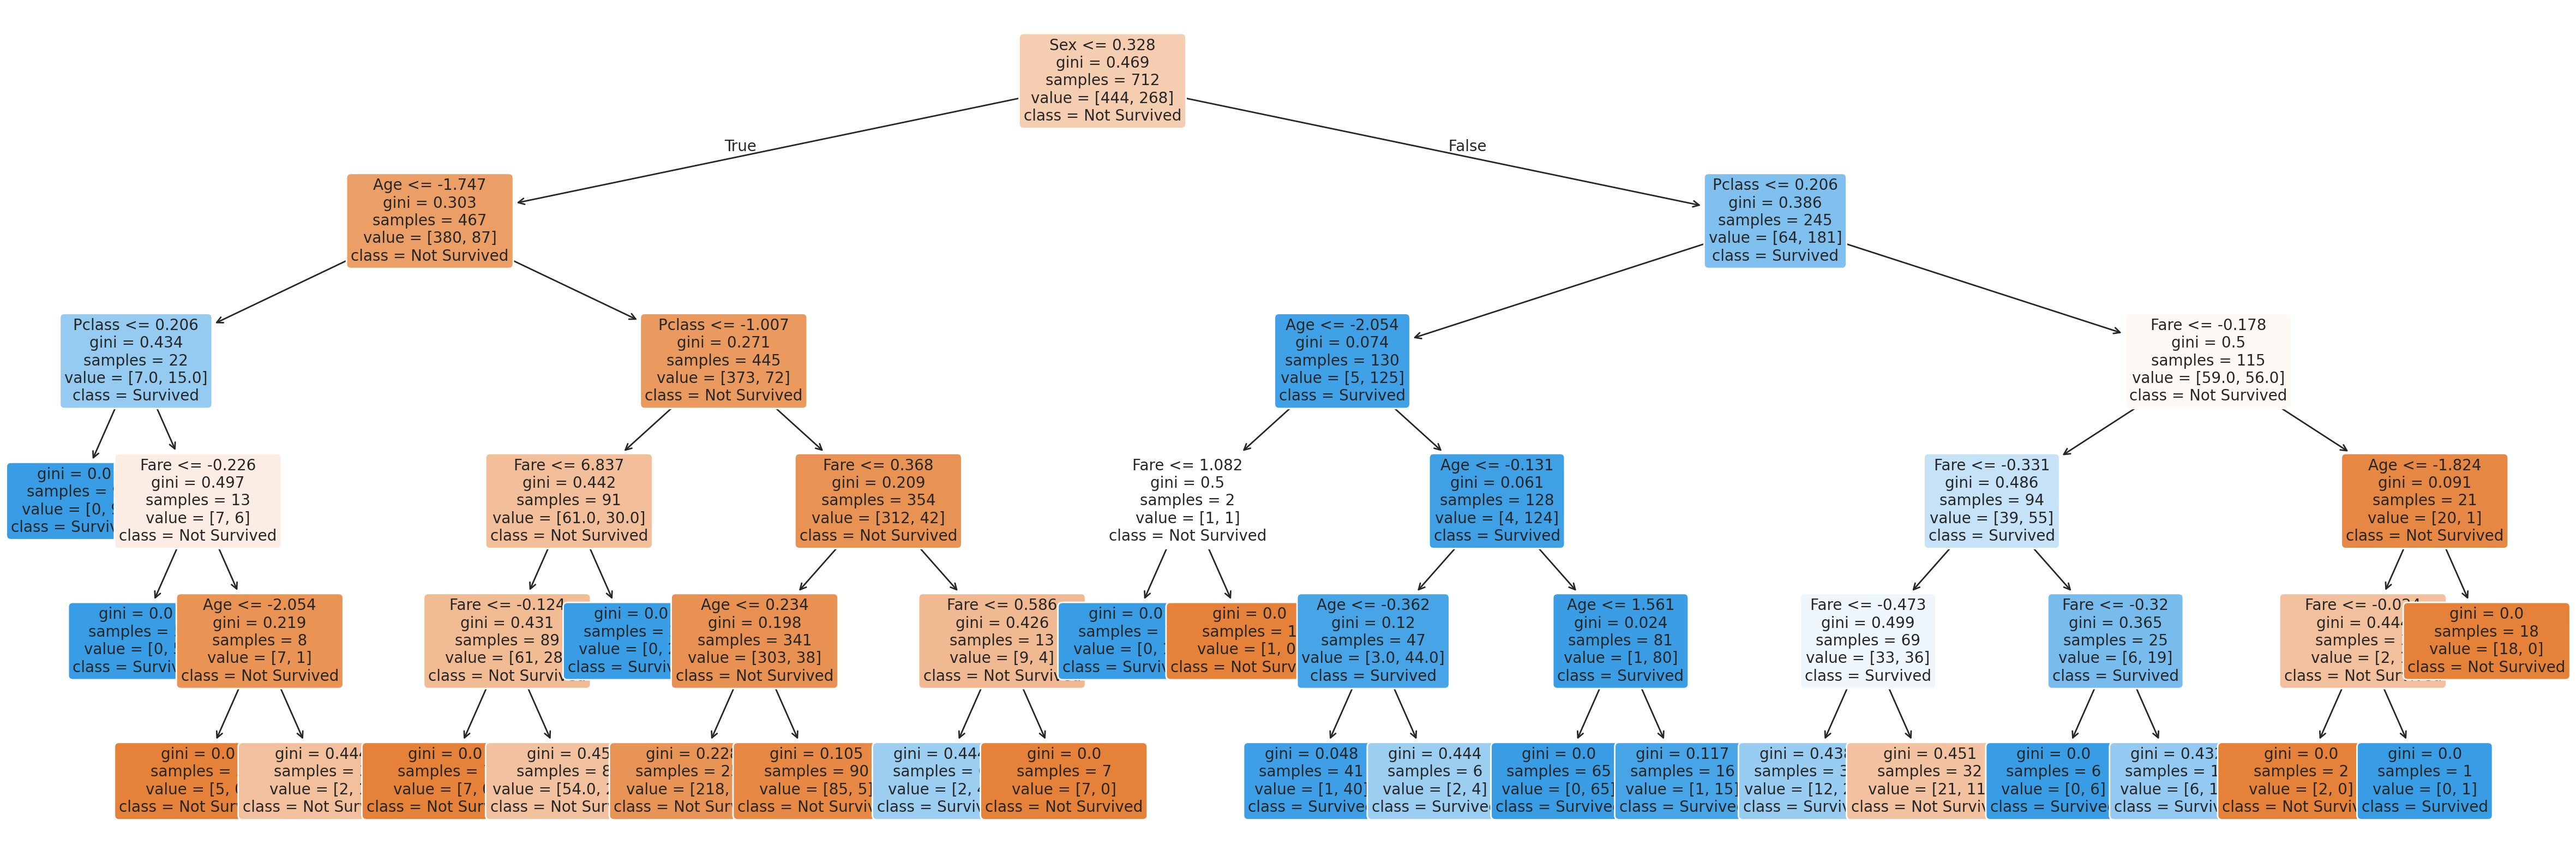

In [72]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30,10), dpi=200)

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

# Random Forest Algorithm

Random Forest is an **ensemble learning algorithm** used for classification and regression. It combines multiple Decision Trees to make more accurate and stable predictions.

![](https://media.geeksforgeeks.org/wp-content/uploads/20251216121929631349/random_forest_algorithm.webp)


---

#### 🧠 Basic Idea

> “Many weak decision trees together make a strong model.”

Instead of relying on one tree, Random Forest builds many trees and takes a **majority vote (classification)** or **average (regression)**.

---

#### 🌳 How It Works

* Create multiple Decision Trees
* Each tree is trained on a **random subset of data**
* Each split considers a **random subset of features**
* Combine outputs of all trees

![](https://media.geeksforgeeks.org/wp-content/uploads/20250627112620729188/tree_1.webp)


---

#### 🗳️ Final Prediction

**Classification:**

* Each tree votes
* Majority vote wins

**Regression:**

* Take average of all tree outputs

---

#### 🔀 Why “Random”?

Randomness comes from:

* **Data sampling (Bootstrap sampling)**
* **Feature selection randomness**

This reduces overfitting.

---

#### 🌟 Key Idea: Bagging

Random Forest uses **Bagging (Bootstrap Aggregation)**:

* Train multiple models independently
* Combine results

---

#### ⚖️ Advantages

- Reduces overfitting (better than single tree)
- Works well on large datasets
- Handles missing values well
- No need for feature scaling

---

#### ❌ Disadvantages

- Slower than single Decision Tree
- Hard to interpret (black box model)
- Uses more memory

---

#### 🧾 One-line Summary

> Random Forest is a collection of many Decision Trees that work together to give more accurate and stable predictions.


# Model Comparison

Model comparison is used to evaluate different machine learning algorithms on the same dataset using a consistent metric (like accuracy, F1-score, etc.). However, the results do not always mean that one model is universally better than the others. A model that performs best on one dataset may perform worse on another due to differences in data distribution, noise, feature relationships, and hyperparameter settings.

So, model comparison should be seen as a **decision-making tool**, not a final judgment. It helps us understand which model is more suitable for a specific problem and helps guide further tuning and experimentation.

---

#### **Key points:**

* Results depend on dataset, not just the algorithm
* No single model is best for all problems (“No Free Lunch Theorem”)
* Performance changes with hyperparameters and feature engineering
* Evaluation metric choice (accuracy, F1, etc.) affects comparison
* Best model = best for *this specific problem*, not always globally best


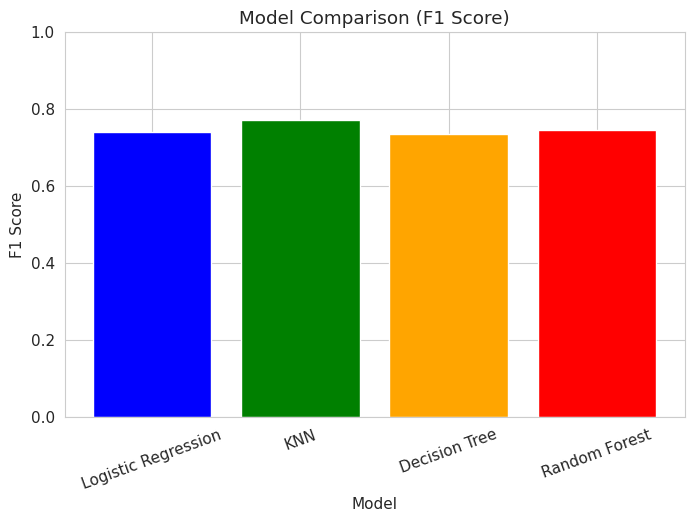

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df = df[["Pclass", "Sex", "Age", "Fare", "Survived"]]
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

colors = ["blue", "green", "orange", "red"]

f1_scores = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    f1_scores.append(f1_score(y_test, y_pred))

# Plot
plt.figure(figsize=(8,5))

plt.bar(models.keys(), f1_scores, color=colors)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Model Comparison (F1 Score)")

plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

# ⚙️ Parameters vs Hyperparameters

## 🧠 Parameters

These are **learned from data during training**.

* The model automatically learns them
* You don’t set them manually

#### Examples:

* Logistic Regression → weights (w), bias (b)
* Decision Tree → split rules
* Random Forest → tree structures

---

## ⚙️ Hyperparameters

These are **set by you before training**.

* Control how the model learns
* Need tuning for best performance

#### Examples (important ones):

**🌲 Random Forest**

* `n_estimators` → number of trees
* `max_depth` → depth of each tree
* `min_samples_split` → minimum samples to split a node

**🌳 Decision Tree**

* `max_depth`
* `min_samples_leaf`

**📍 KNN**

* `n_neighbors (K)`
* distance metric

**📈 Logistic Regression**

* `C` → regularization strength
* `penalty`

---

## 🔍 Hyperparameter Tuning Methods

We need hyperparameter tuning because machine learning models don’t automatically know the best settings to learn from data. Hyperparameters control how a model behaves, and different values can lead to very different performance. So tuning is basically the process of finding the best configuration for your model on your data. There is no universal best setting.
What works for Titanic may not work for another dataset.

#### 1. Grid Search CV

* Tries **all combinations**
* Accurate but slow

#### 2. Random Search CV

* Tries **random combinations**
* Faster and good for large search spaces

![](https://miro.medium.com/0*QKZG5I3autl1HvlY.png)

---

## 🌲 Random Forest Example (GridSearchCV + RandomizedSearchCV)

#### 📌 Code Setup

```python id="rf_tuning_01"
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df = df[["Pclass", "Sex", "Age", "Fare", "Survived"]]
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```

---

#### 🌳 1. Grid Search CV

```python id="grid_rf"
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params (GridSearch):", grid.best_params_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred))
```

---

#### 🎲 2. Random Search CV

```python id="random_rf"
from scipy.stats import randint

param_dist = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(2, 15),
    "min_samples_split": randint(2, 20)
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params (RandomSearch):", random_search.best_params_)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred))
```

---

## ⚡ Key Difference

| Method        | Idea                   | Speed  | Accuracy |
| ------------- | ---------------------- | ------ | -------- |
| Grid Search   | tries all combinations | ❌ slow | ✅ best   |
| Random Search | tries random combos    | ✅ fast | ✅ good   |

---

## 🧾 One-line Summary

> Parameters are learned by the model, while hyperparameters are set by us and tuned using Grid Search or Random Search to improve performance.


In [74]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df = df[["Pclass", "Sex", "Age", "Fare", "Survived"]]
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [75]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params (GridSearch):", grid.best_params_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred))

Best Params (GridSearch): {'max_depth': 5, 'n_estimators': 50}
F1 Score: 0.746268656716418


In [76]:
from scipy.stats import randint

param_dist = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(2, 15),
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params (RandomSearch):", random_search.best_params_)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred))

Best Params (RandomSearch): {'max_depth': 8, 'n_estimators': 229}
F1 Score: 0.7611940298507462
